[*] Fetching 3000 x 15m candles for SOL/USDT...
    1000 candles | 2026-04-10 09:45:00 → 2026-04-20 19:30:00
[*] Usable rows: 954 | Classes → 0:873 1:50 2:31
    Best iteration: 499

  🏛️  QUANT TERMINAL v7  │  SOL/USDT  │  15m
  Accuracy (test)    : 92.67%
  P(Neutral)         : 96.5%
  P(Long  TP hit)    : 0.4%
  P(Short TP hit)    : 3.1%
  ADX                : 23.32  (❌ RANGING)
──────────────────────────────────────────────────────────
  SIGNAL  : 🧊  NO TRADE — ADX 23.3 < 25

  [No closed trades yet]


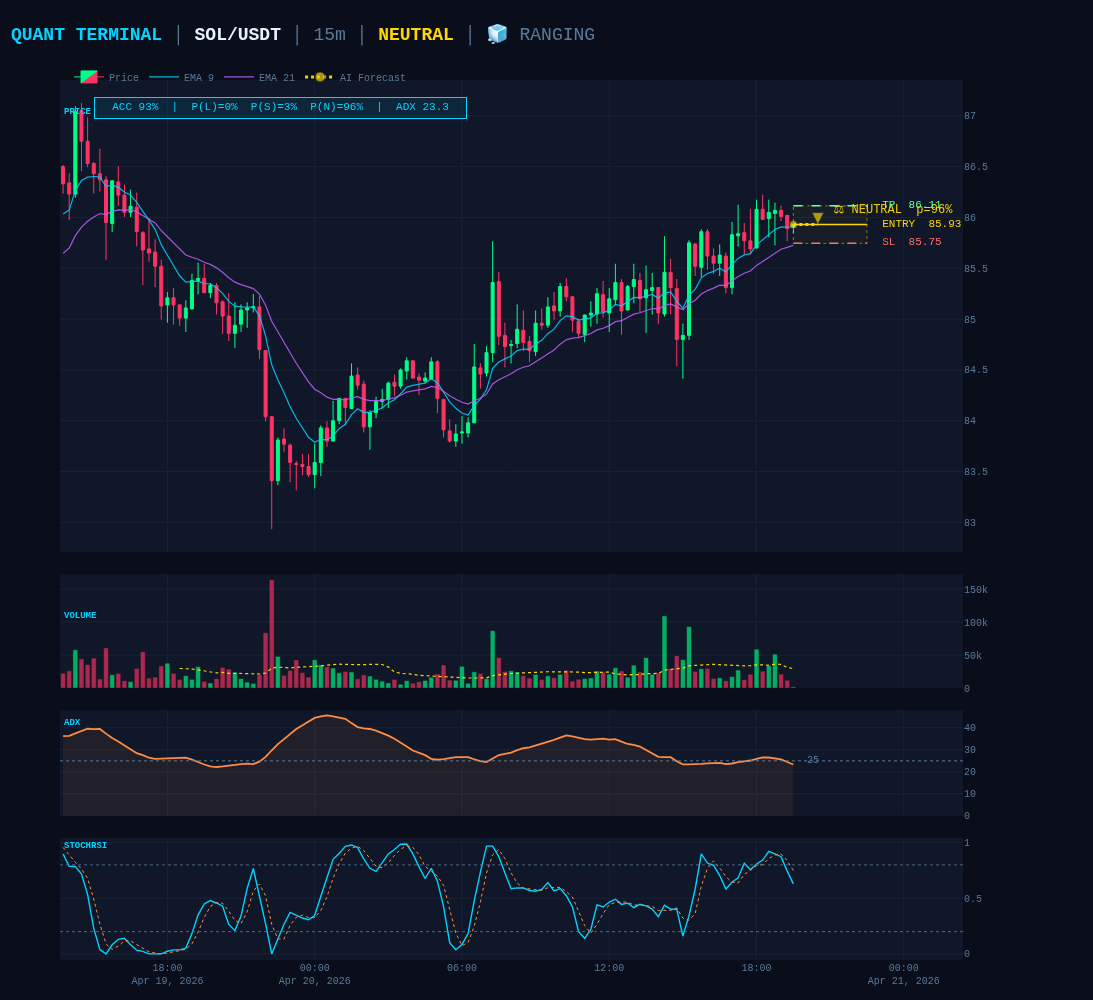

[✓] Dashboard rendered.


In [13]:
import ccxt
import pandas as pd
import numpy as np
import ta
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.utils.class_weight import compute_sample_weight
from datetime import datetime, timedelta
import os
import json
import warnings

warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# CONFIGURATION
# ---------------------------------------------------------------------------
SYMBOL          = 'SOL/USDT'
TIMEFRAME       = '15m'
DATA_LIMIT      = 3000
DB_FILE         = 'quant_memory_v7.json'
INITIAL_CAPITAL = 1000
RISK_PER_TRADE  = 0.02
ADX_THRESHOLD   = 25
ATR_SL_MULT     = 1.5
ATR_TP_MULT     = 3.0
LOOKAHEAD       = 16

# ---------------------------------------------------------------------------
# VISUAL THEME  — Bloomberg Terminal meets Cyberpunk
# ---------------------------------------------------------------------------
THEME = dict(
    bg          = '#0a0e1a',        # Deep navy-black background
    panel       = '#0f1729',        # Slightly lighter panels
    grid        = '#1a2235',        # Subtle grid lines
    border      = '#1e3a5f',        # Blue-tinted borders
    text_main   = '#e8f4fd',        # Crisp white-blue text
    text_dim    = '#5a7a9a',        # Muted secondary text
    accent_blue = '#00d4ff',        # Electric cyan — primary accent
    accent_gold = '#ffd700',        # Gold for neutrals / labels
    bull_green  = '#00ff88',        # Vivid emerald for longs
    bear_red    = '#ff3366',        # Hot coral-red for shorts
    sl_red      = '#ff6b6b',        # Softer stop-loss red
    tp_green    = '#69ff97',        # Target green
    vol_blue    = '#1e90ff',        # Volume bars
    adx_orange  = '#ff8c42',        # ADX line
    ema_cyan    = '#00d4ff',        # EMA fast
    ema_purple  = '#bf5fff',        # EMA slow
    stoch_k     = '#00d4ff',
    stoch_d     = '#ff8c42',
)

# ---------------------------------------------------------------------------
# MAIN CLASS
# ---------------------------------------------------------------------------
class EliteQuantScalper:

    def __init__(self, symbol, timeframe):
        self.symbol    = symbol
        self.timeframe = timeframe
        self.signal    = None          # Populated after training
        self.trade_box = None          # Trade zone box data

        try:
            self.exchange = ccxt.binance({'enableRateLimit': True})
        except Exception as e:
            raise RuntimeError(f"[!] Exchange init failed: {e}")

        self.model = XGBClassifier(
            n_estimators          = 500,
            max_depth             = 5,
            learning_rate         = 0.01,
            objective             = 'multi:softprob',
            num_class             = 3,
            subsample             = 0.8,
            colsample_bytree      = 0.8,
            random_state          = 42,
            tree_method           = 'hist',
            early_stopping_rounds = 50,
            eval_metric           = 'mlogloss'
        )

    # -----------------------------------------------------------------------
    def fetch_data(self):
        try:
            print(f"[*] Fetching {DATA_LIMIT} x {TIMEFRAME} candles for {self.symbol}...")
            ohlcv = self.exchange.fetch_ohlcv(self.symbol, self.timeframe, limit=DATA_LIMIT)
            if not ohlcv or len(ohlcv) < 200:
                raise ValueError(f"Insufficient data: {len(ohlcv)} candles")
        except Exception as e:
            raise RuntimeError(f"[!] Data fetch failed: {e}")

        df = pd.DataFrame(ohlcv, columns=['timestamp','open','high','low','close','volume'])
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
        print(f"    {len(df)} candles | {df['timestamp'].iloc[0]} → {df['timestamp'].iloc[-1]}")
        return df

    # -----------------------------------------------------------------------
    def generate_indicators(self, df):
        close = df['close']

        stoch = ta.momentum.StochRSIIndicator(close, window=14)
        df['stoch_rsi_k']   = stoch.stochrsi_k()
        df['stoch_rsi_d']   = stoch.stochrsi_d()
        df['stoch_kd_diff'] = df['stoch_rsi_k'] - df['stoch_rsi_d']

        ema_fast        = ta.trend.EMAIndicator(close, window=9).ema_indicator()
        ema_slow        = ta.trend.EMAIndicator(close, window=21).ema_indicator()
        df['ema_fast']  = ema_fast
        df['ema_slow']  = ema_slow
        df['ema_delta'] = (ema_fast / ema_slow) - 1

        adx_ind  = ta.trend.ADXIndicator(df['high'], df['low'], close, window=14)
        df['adx'] = adx_ind.adx()

        df['atr']      = ta.volatility.AverageTrueRange(
                             df['high'], df['low'], close, window=14
                         ).average_true_range()
        df['atr_norm'] = df['atr'] / close

        vol_mean    = df['volume'].rolling(20).mean()
        vol_std     = df['volume'].rolling(20).std()
        df['vol_z'] = (df['volume'] - vol_mean) / vol_std

        return df

    # -----------------------------------------------------------------------
    def vectorize_triple_barrier(self, df):
        close  = df['close'].values
        open_  = df['open'].values
        high   = df['high'].values
        low    = df['low'].values
        atr    = df['atr'].values
        n      = len(df)
        labels = np.full(n, np.nan)

        long_tp  = close + atr * ATR_TP_MULT
        long_sl  = close - atr * ATR_SL_MULT
        short_tp = close - atr * ATR_TP_MULT
        short_sl = close + atr * ATR_SL_MULT

        for i in range(n - LOOKAHEAD):
            label = 0
            for j in range(i + 1, i + LOOKAHEAD + 1):
                h, l, o = high[j], low[j], open_[j]
                l_tp = h >= long_tp[i]
                l_sl = l <= long_sl[i]
                s_tp = l <= short_tp[i]
                s_sl = h >= short_sl[i]

                if l_tp and s_tp:
                    label = 1 if abs(o - long_tp[i]) <= abs(o - short_tp[i]) else 2
                    break
                elif l_tp and not l_sl:
                    label = 1; break
                elif s_tp and not s_sl:
                    label = 2; break
                elif l_sl or s_sl:
                    label = 0; break
            labels[i] = label

        df['target'] = labels
        return df

    # -----------------------------------------------------------------------
    def train_and_calibrate(self, df):
        features = ['stoch_rsi_k', 'stoch_rsi_d', 'stoch_kd_diff',
                    'ema_delta', 'adx', 'atr_norm', 'vol_z']

        train_df = df.dropna(subset=['target'] + features).copy()
        X = train_df[features]
        y = train_df['target'].astype(int)

        dist = dict(y.value_counts().sort_index())
        print(f"[*] Usable rows: {len(X)} | Classes → 0:{dist.get(0,0)} 1:{dist.get(1,0)} 2:{dist.get(2,0)}")

        n       = len(X)
        split   = int(n * 0.80)
        cal_idx = int(split * 0.70)

        X_train = X.iloc[:cal_idx];       y_train = y.iloc[:cal_idx]
        X_cal   = X.iloc[cal_idx:split];  y_cal   = y.iloc[cal_idx:split]
        X_test  = X.iloc[split:];         y_test  = y.iloc[split:]

        sw = compute_sample_weight('balanced', y_train)
        self.model.fit(X_train, y_train, sample_weight=sw,
                       eval_set=[(X_cal, y_cal)], verbose=False)
        print(f"    Best iteration: {self.model.best_iteration}")

        try:
            calibrator = CalibratedClassifierCV(
                estimator=self.model, method='sigmoid', cv='prefit')
            calibrator.fit(X_cal, y_cal)
        except Exception:
            calibrator = self._manual_sigmoid_calibrate(X_cal, y_cal)

        acc      = accuracy_score(y_test, calibrator.predict(X_test))
        live_row = df[features].dropna().tail(1)
        probs    = calibrator.predict_proba(live_row)[0]

        return probs, acc, calibrator

    # -----------------------------------------------------------------------
    def _manual_sigmoid_calibrate(self, X_cal, y_cal):
        from sklearn.linear_model import LogisticRegression
        raw_probs   = self.model.predict_proba(X_cal)
        calibrators = []
        for c in range(3):
            lr = LogisticRegression(max_iter=1000)
            lr.fit(raw_probs[:, c].reshape(-1, 1), (y_cal == c).astype(int))
            calibrators.append(lr)
        base = self.model

        class ManualCal:
            def __init__(self, b, cs): self._b = b; self._cs = cs
            def predict_proba(self, X):
                rp  = self._b.predict_proba(X)
                out = np.column_stack([
                    self._cs[c].predict_proba(rp[:, c].reshape(-1,1))[:,1]
                    for c in range(3)])
                s = out.sum(axis=1, keepdims=True)
                return out / np.where(s == 0, 1, s)
            def predict(self, X): return np.argmax(self.predict_proba(X), axis=1)

        return ManualCal(base, calibrators)

    # -----------------------------------------------------------------------
    def update_trade_memory(self, current_df):
        if not os.path.exists(DB_FILE):
            with open(DB_FILE, 'w') as f: json.dump([], f)
        with open(DB_FILE, 'r') as f: history = json.load(f)

        for trade in history:
            if trade['status'] != 'open': continue
            trade_time = pd.to_datetime(trade['time'])
            recent     = current_df[current_df['timestamp'] > trade_time]
            if recent.empty: continue

            if trade['side'] == 'long':
                tp_mask = recent['high'] >= trade['tp']
                sl_mask = recent['low']  <= trade['sl']
            else:
                tp_mask = recent['low']  <= trade['tp']
                sl_mask = recent['high'] >= trade['sl']

            tp_hit, sl_hit = tp_mask.any(), sl_mask.any()
            if tp_hit and sl_hit:
                first_tp = recent[tp_mask].index[0]
                first_sl = recent[sl_mask].index[0]
                result   = 'win' if first_tp < first_sl else 'loss'
                trade.update({'status': 'closed', 'result': result})
            elif tp_hit:
                trade.update({'status': 'closed', 'result': 'win'})
            elif sl_hit:
                trade.update({'status': 'closed', 'result': 'loss'})

        with open(DB_FILE, 'w') as f: json.dump(history, f, indent=4)
        return history

    # -----------------------------------------------------------------------
    def log_new_prediction(self, price, tp, sl, side, prob, history):
        history.append({
            "time": datetime.now().strftime("%Y-%m-%d %H:%M"),
            "side": side, "price": float(price),
            "tp": float(tp), "sl": float(sl),
            "prob": float(prob), "status": "open", "result": "pending"
        })
        with open(DB_FILE, 'w') as f: json.dump(history[-100:], f, indent=4)

    # -----------------------------------------------------------------------
    def performance_report(self, history):
        closed   = [t for t in history if t['status'] == 'closed']
        if not closed:
            print("\n  [No closed trades yet]"); return
        wins     = sum(1 for t in closed if t['result'] == 'win')
        losses   = len(closed) - wins
        win_rate = wins / len(closed)
        b        = ATR_TP_MULT / ATR_SL_MULT
        print(f"\n{'─'*55}")
        print(f"  📈 LIVE TRADE LOG  ({len(closed)} closed trades)")
        print(f"  Wins: {wins}  |  Losses: {losses}  |  Win Rate: {win_rate:.1%}")
        if wins > 0 and losses > 0:
            q     = 1 - win_rate
            kelly = max(0, (win_rate * b - q) / b)
            print(f"  Kelly: {kelly:.2%}  |  Half-Kelly: {kelly/2:.2%}")
        print(f"{'─'*55}")

    # -----------------------------------------------------------------------
    # ELITE DASHBOARD
    # -----------------------------------------------------------------------
    def plot_dashboard(self, df, probs, accuracy, history):
        """
        5-panel Bloomberg-style terminal:
          Row 1 (60%): Candlesticks + EMA ribbon + Trade zone box + Forecast line
          Row 2 (15%): Volume bars with z-score coloring
          Row 3 (12%): ADX with threshold line
          Row 4 (13%): StochRSI K/D with overbought/oversold bands
        """
        p_neutral, p_long, p_short = probs
        tail       = df.tail(120).copy().reset_index(drop=True)
        last_ts    = tail['timestamp'].iloc[-1]
        last_price = tail['close'].iloc[-1]
        last_atr   = tail['atr'].iloc[-1]
        last_adx   = tail['adx'].iloc[-1]

        # Determine signal
        is_trending = last_adx > ADX_THRESHOLD
        if is_trending and p_long > 0.60:
            sig = 'LONG'
        elif is_trending and p_short > 0.60:
            sig = 'SHORT'
        else:
            sig = 'NEUTRAL'

        # Candle colors
        candle_inc = THEME['bull_green']
        candle_dec = THEME['bear_red']

        fig = make_subplots(
            rows=4, cols=1,
            shared_xaxes=True,
            vertical_spacing=0.025,
            row_heights=[0.58, 0.14, 0.13, 0.15],
            subplot_titles=('', '', '', '')
        )

        # ── ROW 1: PRICE ────────────────────────────────────────────────────

        # Candlesticks
        fig.add_trace(go.Candlestick(
            x=tail['timestamp'],
            open=tail['open'], high=tail['high'],
            low=tail['low'],   close=tail['close'],
            name='Price',
            increasing=dict(line=dict(color=candle_inc, width=1),
                            fillcolor=candle_inc),
            decreasing=dict(line=dict(color=candle_dec, width=1),
                            fillcolor=candle_dec),
            whiskerwidth=0.3,
        ), row=1, col=1)

        # EMA Fast
        fig.add_trace(go.Scatter(
            x=tail['timestamp'], y=tail['ema_fast'],
            line=dict(color=THEME['ema_cyan'], width=1.2),
            name='EMA 9', opacity=0.85
        ), row=1, col=1)

        # EMA Slow
        fig.add_trace(go.Scatter(
            x=tail['timestamp'], y=tail['ema_slow'],
            line=dict(color=THEME['ema_purple'], width=1.2),
            name='EMA 21', opacity=0.85
        ), row=1, col=1)

        # ── TRADE ZONE BOX + FORECAST ────────────────────────────────────────
        # Time extent: entry → 4 candles ahead (1 hour visual)
        dt_offset  = timedelta(minutes=15)
        forecast_end = last_ts + dt_offset * 12   # visual end of box

        if sig == 'LONG':
            sl_price  = last_price - last_atr * ATR_SL_MULT
            tp_price  = last_price + last_atr * ATR_TP_MULT
            box_color = 'rgba(0,255,136,0.07)'
            box_line  = THEME['bull_green']
            pred_color= THEME['bull_green']
            fore_price= last_price + last_atr * ATR_TP_MULT * 0.85
            sig_label = f"🚀 LONG  p={p_long:.0%}"
            prob_val  = p_long

        elif sig == 'SHORT':
            sl_price  = last_price + last_atr * ATR_SL_MULT
            tp_price  = last_price - last_atr * ATR_TP_MULT
            box_color = 'rgba(255,51,102,0.07)'
            box_line  = THEME['bear_red']
            pred_color= THEME['bear_red']
            fore_price= last_price - last_atr * ATR_TP_MULT * 0.85
            sig_label = f"📉 SHORT  p={p_short:.0%}"
            prob_val  = p_short

        else:
            sl_price  = last_price - last_atr * 0.5
            tp_price  = last_price + last_atr * 0.5
            box_color = 'rgba(255,215,0,0.04)'
            box_line  = THEME['accent_gold']
            pred_color= THEME['accent_gold']
            fore_price= last_price
            sig_label = f"⚖ NEUTRAL  p={p_neutral:.0%}"
            prob_val  = p_neutral

        # Shaded trade zone (entry to forecast end)
        fig.add_shape(type='rect',
            x0=last_ts, x1=forecast_end,
            y0=min(sl_price, tp_price), y1=max(sl_price, tp_price),
            fillcolor=box_color,
            line=dict(color=box_line, width=0.5, dash='dot'),
            row=1, col=1
        )

        # TP line (horizontal dashed)
        fig.add_shape(type='line',
            x0=last_ts, x1=forecast_end,
            y0=tp_price, y1=tp_price,
            line=dict(color=THEME['tp_green'], width=1.5, dash='dash'),
            row=1, col=1
        )

        # SL line (horizontal dashed)
        fig.add_shape(type='line',
            x0=last_ts, x1=forecast_end,
            y0=sl_price, y1=sl_price,
            line=dict(color=THEME['sl_red'], width=1.5, dash='dash'),
            row=1, col=1
        )

        # Entry line (solid)
        fig.add_shape(type='line',
            x0=last_ts, x1=forecast_end,
            y0=last_price, y1=last_price,
            line=dict(color=THEME['accent_gold'], width=1.5),
            row=1, col=1
        )

        # TP / SL / Entry labels (annotations)
        fig.add_annotation(
            x=forecast_end, y=tp_price,
            text=f"  TP  {tp_price:.2f}",
            font=dict(color=THEME['tp_green'], size=11, family='Courier New'),
            showarrow=False, xanchor='left', row=1, col=1
        )
        fig.add_annotation(
            x=forecast_end, y=sl_price,
            text=f"  SL  {sl_price:.2f}",
            font=dict(color=THEME['sl_red'], size=11, family='Courier New'),
            showarrow=False, xanchor='left', row=1, col=1
        )
        fig.add_annotation(
            x=forecast_end, y=last_price,
            text=f"  ENTRY  {last_price:.2f}",
            font=dict(color=THEME['accent_gold'], size=11, family='Courier New'),
            showarrow=False, xanchor='left', row=1, col=1
        )

        # AI Forecast arrow line (entry → predicted price)
        forecast_x1 = last_ts + dt_offset * 4
        fig.add_trace(go.Scatter(
            x=[last_ts, forecast_x1],
            y=[last_price, fore_price],
            mode='lines+markers+text',
            name='AI Forecast',
            line=dict(color=pred_color, width=3, dash='dot'),
            marker=dict(size=[8, 12], symbol=['circle', 'arrow-bar-up' if sig=='LONG' else 'arrow-bar-down'],
                        color=pred_color),
            text=['', f' {sig_label}'],
            textposition='top right',
            textfont=dict(color=pred_color, size=12, family='Courier New'),
            opacity=0.95,
        ), row=1, col=1)

        # Confidence badge (annotation on price panel)
        fig.add_annotation(
            x=tail['timestamp'].iloc[5], y=tail['high'].max() * 0.9995,
            text=(f"  ACC {accuracy:.0%}  |  "
                  f"P(L)={p_long:.0%}  P(S)={p_short:.0%}  P(N)={p_neutral:.0%}  "
                  f"|  ADX {last_adx:.1f}  "),
            font=dict(color=THEME['accent_blue'], size=11, family='Courier New'),
            bgcolor='rgba(0,212,255,0.08)',
            bordercolor=THEME['accent_blue'],
            borderwidth=1,
            borderpad=4,
            showarrow=False,
            xanchor='left',
            row=1, col=1
        )

        # ── ROW 2: VOLUME ────────────────────────────────────────────────────
        vol_colors = [
            THEME['bull_green'] if c >= o else THEME['bear_red']
            for c, o in zip(tail['close'], tail['open'])
        ]
        fig.add_trace(go.Bar(
            x=tail['timestamp'], y=tail['volume'],
            name='Volume',
            marker_color=vol_colors,
            marker_opacity=0.65,
            showlegend=False
        ), row=2, col=1)

        # 20-period volume MA overlay
        vol_ma = tail['volume'].rolling(20).mean()
        fig.add_trace(go.Scatter(
            x=tail['timestamp'], y=vol_ma,
            line=dict(color=THEME['accent_gold'], width=1.2, dash='dot'),
            name='Vol MA20', showlegend=False
        ), row=2, col=1)

        # ── ROW 3: ADX ───────────────────────────────────────────────────────
        fig.add_trace(go.Scatter(
            x=tail['timestamp'], y=tail['adx'],
            line=dict(color=THEME['adx_orange'], width=1.8),
            fill='tozeroy',
            fillcolor='rgba(255,140,66,0.08)',
            name='ADX', showlegend=False
        ), row=3, col=1)

        # ADX threshold line
        fig.add_hline(
            y=ADX_THRESHOLD,
            line_dash='dot', line_color=THEME['text_dim'], line_width=1,
            row=3, col=1
        )
        fig.add_annotation(
            x=tail['timestamp'].iloc[-1], y=ADX_THRESHOLD,
            text=f'  {ADX_THRESHOLD}',
            font=dict(color=THEME['text_dim'], size=10, family='Courier New'),
            showarrow=False, xanchor='left', row=3, col=1
        )

        # ── ROW 4: STOCHRSI ──────────────────────────────────────────────────
        fig.add_trace(go.Scatter(
            x=tail['timestamp'], y=tail['stoch_rsi_k'],
            line=dict(color=THEME['stoch_k'], width=1.4),
            name='StochRSI %K', showlegend=False
        ), row=4, col=1)

        fig.add_trace(go.Scatter(
            x=tail['timestamp'], y=tail['stoch_rsi_d'],
            line=dict(color=THEME['stoch_d'], width=1.0, dash='dot'),
            name='StochRSI %D', showlegend=False
        ), row=4, col=1)

        # OB/OS bands
        for level, label in [(0.8, 'OB'), (0.2, 'OS')]:
            fig.add_hline(y=level, line_dash='dot',
                          line_color=THEME['text_dim'], line_width=0.8,
                          row=4, col=1)

        # ── LAYOUT ───────────────────────────────────────────────────────────
        # Title
        regime_txt  = '🔥 TRENDING' if is_trending else '🧊 RANGING'
        sig_color   = (THEME['bull_green'] if sig == 'LONG'
                       else THEME['bear_red'] if sig == 'SHORT'
                       else THEME['accent_gold'])

        fig.update_layout(
            template    = 'plotly_dark',
            paper_bgcolor = THEME['bg'],
            plot_bgcolor  = THEME['panel'],
            height      = 1000,
            margin      = dict(l=60, r=130, t=80, b=40),
            title       = dict(
                text=(f"<b style='color:{THEME['accent_blue']}'>QUANT TERMINAL</b>"
                      f"<span style='color:{THEME['text_dim']}'> │ </span>"
                      f"<b style='color:{THEME['text_main']}'>{self.symbol}</b>"
                      f"<span style='color:{THEME['text_dim']}'> │ {self.timeframe} │ </span>"
                      f"<b style='color:{sig_color}'>{sig}</b>"
                      f"<span style='color:{THEME['text_dim']}'> │ {regime_txt}</span>"),
                font=dict(size=18, family='Courier New, monospace'),
                x=0.01, xanchor='left'
            ),
            xaxis_rangeslider_visible = False,
            legend = dict(
                orientation='h',
                x=0.01, y=1.02,
                font=dict(color=THEME['text_dim'], size=10, family='Courier New'),
                bgcolor='rgba(0,0,0,0)'
            ),
            font=dict(family='Courier New, monospace', color=THEME['text_dim']),
        )

        # Grid styling across all rows
        for i in range(1, 5):
            fig.update_xaxes(
                row=i, col=1,
                gridcolor=THEME['grid'],
                showgrid=True,
                zeroline=False,
                tickfont=dict(color=THEME['text_dim'], size=10),
                showticklabels=(i == 4),
            )
            fig.update_yaxes(
                row=i, col=1,
                gridcolor=THEME['grid'],
                showgrid=True,
                zeroline=False,
                tickfont=dict(color=THEME['text_dim'], size=10),
                side='right',
            )

        # Row labels (mini axis titles)
        for row_n, label in [(1,'PRICE'), (2,'VOLUME'), (3,'ADX'), (4,'STOCHRSI')]:
            fig.add_annotation(
                xref='paper', yref='paper',
                x=0.002,
                y={1: 0.97, 2: 0.39, 3: 0.26, 4: 0.12}[row_n],
                text=f'<b>{label}</b>',
                font=dict(color=THEME['accent_blue'], size=9, family='Courier New'),
                showarrow=False, xanchor='left',
            )

        fig.show()
        print("[✓] Dashboard rendered.")

# ===========================================================================
# EXECUTION
# ===========================================================================
if __name__ == '__main__':

    quant   = EliteQuantScalper(SYMBOL, TIMEFRAME)
    df      = quant.fetch_data()
    df      = quant.generate_indicators(df)
    df      = quant.vectorize_triple_barrier(df)

    probs, accuracy, calibrator = quant.train_and_calibrate(df)
    history = quant.update_trade_memory(df)

    p_neutral, p_long, p_short = probs
    current_price = df['close'].iloc[-1]
    current_atr   = df['atr'].iloc[-1]
    current_adx   = df['adx'].iloc[-1]
    is_trending   = current_adx > ADX_THRESHOLD

    # ── TERMINAL OUTPUT ──────────────────────────────────────────────────────
    print("\n" + "="*58)
    print(f"  🏛️  QUANT TERMINAL v7  │  {SYMBOL}  │  {TIMEFRAME}")
    print("="*58)
    print(f"  Accuracy (test)    : {accuracy:.2%}")
    print(f"  P(Neutral)         : {p_neutral:.1%}")
    print(f"  P(Long  TP hit)    : {p_long:.1%}")
    print(f"  P(Short TP hit)    : {p_short:.1%}")
    print(f"  ADX                : {current_adx:.2f}  "
          f"({'✅ TRENDING' if is_trending else '❌ RANGING'})")
    print("─"*58)

    if is_trending:
        if p_long > 0.60:
            sl      = current_price - current_atr * ATR_SL_MULT
            tp      = current_price + current_atr * ATR_TP_MULT
            sl_dist = current_price - sl
            pos     = (INITIAL_CAPITAL * RISK_PER_TRADE) / sl_dist
            print(f"  SIGNAL  : 🚀  LONG")
            print(f"  Entry   : {current_price:.4f}")
            print(f"  Stop    : {sl:.4f}  (−{sl_dist:.4f} / {ATR_SL_MULT}×ATR)")
            print(f"  Target  : {tp:.4f}  (+{tp-current_price:.4f} / {ATR_TP_MULT}×ATR)")
            print(f"  Size    : {pos:.4f} {SYMBOL.split('/')[0]}")
            print(f"  R:R     : 1:{ATR_TP_MULT/ATR_SL_MULT:.1f}")
            quant.log_new_prediction(current_price, tp, sl, 'long', p_long, history)

        elif p_short > 0.60:
            sl      = current_price + current_atr * ATR_SL_MULT
            tp      = current_price - current_atr * ATR_TP_MULT
            sl_dist = sl - current_price
            pos     = (INITIAL_CAPITAL * RISK_PER_TRADE) / sl_dist
            print(f"  SIGNAL  : 📉  SHORT")
            print(f"  Entry   : {current_price:.4f}")
            print(f"  Stop    : {sl:.4f}  (+{sl_dist:.4f} / {ATR_SL_MULT}×ATR)")
            print(f"  Target  : {tp:.4f}  (−{current_price-tp:.4f} / {ATR_TP_MULT}×ATR)")
            print(f"  Size    : {pos:.4f} {SYMBOL.split('/')[0]}")
            print(f"  R:R     : 1:{ATR_TP_MULT/ATR_SL_MULT:.1f}")
            quant.log_new_prediction(current_price, tp, sl, 'short', p_short, history)

        else:
            print(f"  SIGNAL  : ⚖️   NO CONVICTION")
    else:
        print(f"  SIGNAL  : 🧊  NO TRADE — ADX {current_adx:.1f} < {ADX_THRESHOLD}")

    print("="*58)
    quant.performance_report(history)

    # ── RENDER DASHBOARD ─────────────────────────────────────────────────────
    quant.plot_dashboard(df, probs, accuracy, history)